In [1]:
%pip install numpy
%pip install matplotlib
%pip install imageio

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from __future__ import annotations
from helpers.env import SlipperyGridWorld, ACTIONS
from helpers.viz import greedy_policy_from_V, plot_and_evaluate, plot_convergence
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Available actions
# Action mapping: 0=Up, 1=Right, 2=Down, 3=Left
print(ACTIONS)

(0, 1, 2, 3)


In [4]:
# =============================CONFIGURATION BLOCK============================= #
# |                   Change the parameters and see what happens              | #
# =============================CONFIGURATION BLOCK============================= #

# Example parameters set up for environment
num_rows = 7
num_cols = 7
start_state = (1, 1)
goal_state = (5, 5)
slip_prob = 0.2
random_seed = 987
step_reward = -1
goal_reward = 10

# VI parameters
max_number_iterations = 100 # max number of value iterations
threshold = 1e-5 # stopping condition
gamma = 0.99 # discount factor

# Evaluation parameters
max_steps_in_env = 150 # used for episodic evaluation

In [5]:
from helpers.rl import value_iteration

env = SlipperyGridWorld(rows=num_rows, cols=num_cols, start=start_state, goal=goal_state,
                        step_reward=step_reward, goal_reward=goal_reward,
                        slip_prob=slip_prob, max_steps=max_steps_in_env, seed=random_seed)
env.reset()

V, n_iter = value_iteration(env, max_iterations=max_number_iterations, gamma=gamma, threshold=threshold)
print(f"Value Iteration converged after {n_iter} iterations.")

Value Iteration converged after 35 iterations.


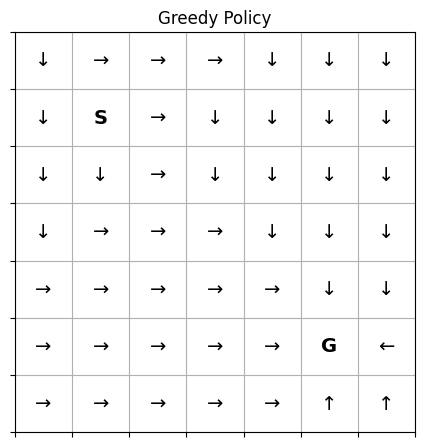

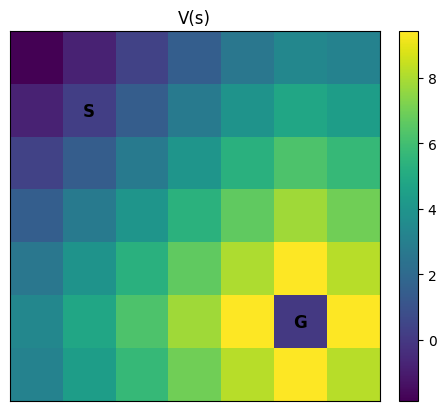

{'avg_return': 0.74, 'std_return': 2.2874, 'success_rate': 1.0, 'avg_steps': 10.26}


In [6]:
policy_plot_name = "policy_VI.png"
value_plot_name = "value_VI.png"
gif_name = "episode_VI.gif"
n_val_episodes = 50

pi = greedy_policy_from_V(V, env, gamma)

metrics = plot_and_evaluate(
    env,
    policy=pi,
    V=V,
    policy_plot_name=policy_plot_name,
    value_plot_name=value_plot_name,
    policy_title="Greedy Policy",
    value_title="V(s)",
    n_val_episodes=n_val_episodes,
    seed=random_seed,
    gif_name=gif_name,
    fps=6,
 )
print(metrics)

# Q-learning

In [7]:
# Q-Learning hyperparameters
n_episodes_ql = 10_000
alpha = 0.2
epsilon = 0.80
epsilon_min = 0.01
epsilon_decay = 0.9999


In [8]:
from helpers.rl import (
    value_iteration,
    q_learning,
    sarsa,
)

In [9]:
env.reset()

Q, rewards_ql = q_learning(
    env,
    n_episodes=n_episodes_ql,
    alpha=alpha,
    gamma=gamma,
    epsilon=epsilon,
    epsilon_min=epsilon_min,
    epsilon_decay=epsilon_decay,
    seed=random_seed,
)

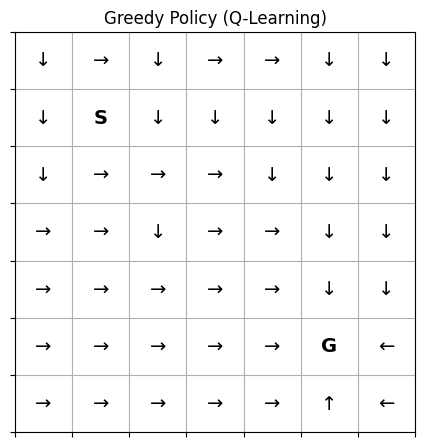

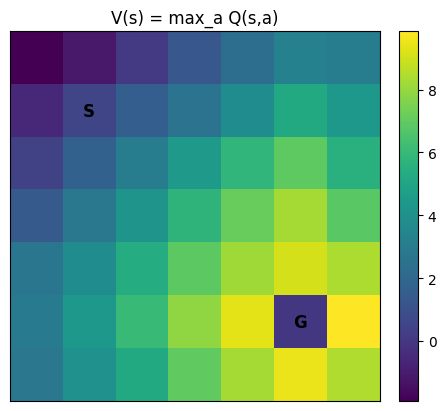

{'avg_return': 0.42, 'std_return': 2.5067, 'success_rate': 1.0, 'avg_steps': 10.58}


In [10]:
policy_plot_name_ql = "policy_QL.png"
value_plot_name_ql  = "value_QL.png"
gif_name_ql         = "episode_QL.gif"
n_val_episodes_ql   = 50

metrics_ql = plot_and_evaluate(
    env,
    Q=Q,
    policy_plot_name=policy_plot_name_ql,
    value_plot_name=value_plot_name_ql,
    policy_title="Greedy Policy (Q-Learning)",
    value_title="V(s) = max_a Q(s,a)",
    n_val_episodes=n_val_episodes_ql,
    seed=random_seed,
    gif_name=gif_name_ql,
    fps=6,
 )
print(metrics_ql)


# Sarsa

In [11]:
# sarsa parameters
n_episodes_sarsa = 10_000
alpha_sarsa = 0.2
epsilon_sarsa = 0.80
epsilon_min_sarsa = 0.01
epsilon_decay_sarsa = 0.9999


In [12]:
env.reset()

Q, rewards_sarsa = sarsa(
    env,
    n_episodes=n_episodes_sarsa,
    alpha=alpha_sarsa,
    gamma=gamma,
    epsilon=epsilon_sarsa,
    epsilon_min=epsilon_min_sarsa,
    epsilon_decay=epsilon_decay_sarsa,
    seed=random_seed,
)

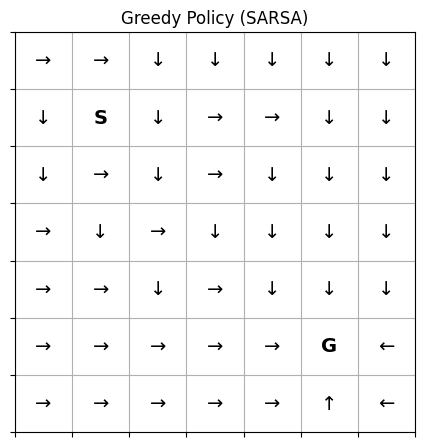

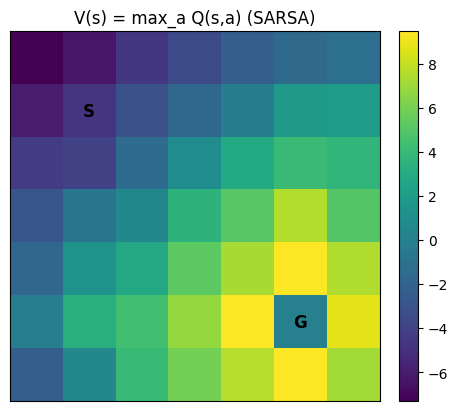

{'avg_return': 0.44, 'std_return': 2.8154, 'success_rate': 1.0, 'avg_steps': 10.56}


In [13]:
policy_plot_name_sarsa = "policy_SARSA.png"
value_plot_name_sarsa  = "value_SARSA.png"
gif_name_sarsa         = "episode_SARSA.gif"

metrics_sarsa = plot_and_evaluate(
    env,
    Q=Q,
    policy_plot_name=policy_plot_name_sarsa,
    value_plot_name=value_plot_name_sarsa,
    policy_title="Greedy Policy (SARSA)",
    value_title="V(s) = max_a Q(s,a) (SARSA)",
    n_val_episodes=n_val_episodes_ql,
    seed=random_seed,
    gif_name=gif_name_sarsa,
    fps=6,
 )
print(metrics_sarsa)


# Convergence comparison

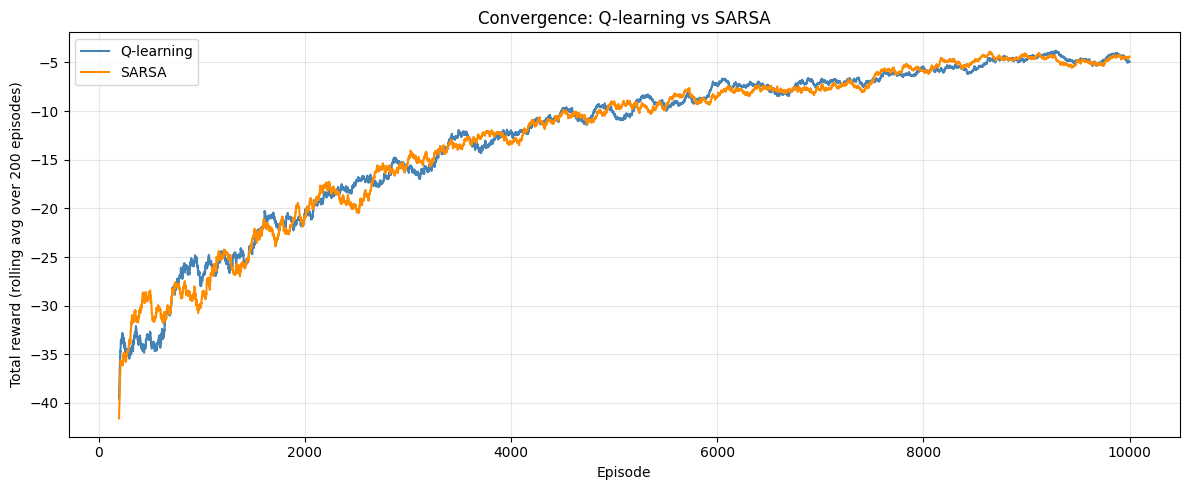

In [14]:
plot_convergence(
    rewards_ql,
    rewards_sarsa,
    window=200,
    filename="convergence.png",
 )
